### Imports

In [6]:
from langgraph.graph import StateGraph,START,END

### define state

In [16]:
from typing import TypedDict
class TemperatureState(TypedDict):
    temp_celsius:float
    temp_fahrenheit:float
    weather_label:str

### convert temperature Function (first node)

In [28]:
def convert_temp(state):
    celsius = state["temp_celsius"]
    fahrenheit = (celsius * 9/5) + 32
    state["temp_fahrenheit"] = fahrenheit
    return state

### lebel weather

In [29]:
def label_weather(state:TemperatureState)->TemperatureState:
    fahrenheit = state['temp_fahrenheit']
    if fahrenheit>=86:
        state["weather_label"]="Hot"
    elif fahrenheit>=68:
        state["weather_label"]="Warm"
    else:
        state["weather_label"]="Cool"
    return state

### define and compile Graph

In [30]:
graph = StateGraph(TemperatureState)

graph.add_node('convert_temp',convert_temp)
graph.add_node('label_weather',label_weather)

#add edges
graph.add_edge(START,'convert_temp')
graph.add_edge('convert_temp','label_weather')
graph.add_edge('label_weather',END)

#complie
workflow = graph.compile()


### execute the graph

In [31]:
initial_state={'temp_celsius': 25.0}
final_state=workflow.invoke(initial_state)
final_state

{'temp_celsius': 25.0, 'temp_fahrenheit': 77.0, 'weather_label': 'Warm'}

### Visualize Graph

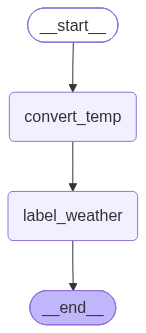

In [32]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())